
# Gaussian Distribution là gì?  
## Demo: Vẽ phân phối Gaussian từ dữ liệu Titanic

Notebook này giúp bạn hiểu:

- Gaussian Distribution / Normal Distribution là gì
- Vì sao nó có dạng hình chuông
- Mean và Standard Deviation ảnh hưởng thế nào
- Cách lấy dữ liệu thật từ Titanic
- Cách vẽ histogram và đường Gaussian bằng Python



# 1. Gaussian Distribution là gì?

**Gaussian Distribution**, hay còn gọi là **Normal Distribution / Phân phối chuẩn**, là một dạng phân phối xác suất có hình dạng giống **quả chuông**.

Nó thường xuất hiện trong dữ liệu đời thật, ví dụ:

- Chiều cao con người
- Điểm thi
- Cân nặng
- Sai số đo lường
- Tuổi của một nhóm người
- Noise trong dữ liệu AI/ML

Ý tưởng đơn giản:

> Phần lớn dữ liệu sẽ tập trung quanh giá trị trung bình.  
> Những giá trị quá thấp hoặc quá cao sẽ ít xuất hiện hơn.

Ví dụ với chiều cao:

- Nhiều người cao quanh 165–175 cm
- Ít người quá thấp hoặc quá cao



# 2. Hình dạng trực giác

Phân phối Gaussian thường có dạng:

```text
          .
        .   .
      .       .
    .           .
  .               .
.                   .
-------------------------
 thấp     trung bình    cao
```

Điểm cao nhất nằm gần **mean / trung bình**.

Hai bên giảm dần vì các giá trị quá xa trung bình thường ít xuất hiện.



# 3. Hai tham số quan trọng

Gaussian Distribution được quyết định chủ yếu bởi 2 tham số:

## 1. Mean / Trung bình

Ký hiệu:

$$
\mu
$$

Mean cho biết trung tâm của dữ liệu nằm ở đâu.

## 2. Standard Deviation / Độ lệch chuẩn

Ký hiệu:

$$
\sigma
$$

Standard deviation cho biết dữ liệu phân tán rộng hay hẹp.

- Standard deviation nhỏ → dữ liệu tập trung sát mean
- Standard deviation lớn → dữ liệu trải rộng hơn



# 4. Công thức Gaussian

Công thức mật độ xác suất của Gaussian Distribution là:

$$
f(x)=\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}
$$

Trong đó:

- $x$: một giá trị dữ liệu
- $\mu$: mean / trung bình
- $\sigma$: standard deviation / độ lệch chuẩn
- $e$: hằng số Euler
- $\pi$: số pi

Bạn chưa cần học thuộc công thức này ngay.

Điều quan trọng hơn là hiểu:

> Gaussian Distribution là đường cong được tạo từ mean và standard deviation.



# 5. Import thư viện cần dùng


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm



# 6. Demo nhanh: tự tạo dữ liệu Gaussian

Trước khi dùng dữ liệu Titanic, ta tạo dữ liệu giả lập để nhìn rõ hình chuông.


In [2]:

# Tạo 1000 điểm dữ liệu có phân phối gần Gaussian
# loc = mean, scale = standard deviation
data = np.random.normal(loc=50, scale=10, size=1000)

print(data[:10])


[44.45038594 38.66984753 70.38892269 40.61827441 61.86372365 57.70469792
 54.82118468 33.29924553 46.26413863 34.69996621]



# 7. Vẽ histogram của dữ liệu giả lập


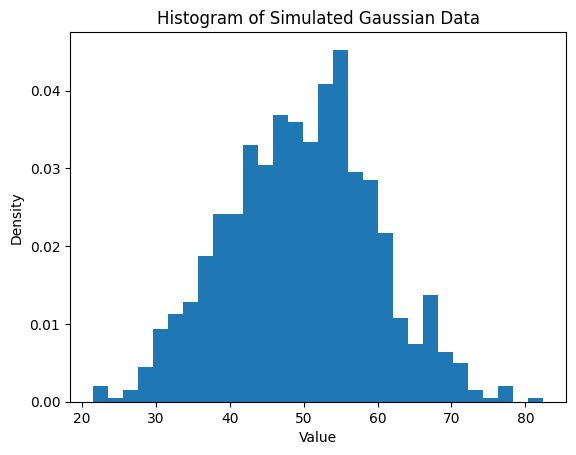

In [3]:

plt.hist(data, bins=30, density=True)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram of Simulated Gaussian Data")

plt.show()



# 8. Vẽ histogram kèm đường Gaussian

Ta sẽ:

1. Tính mean
2. Tính standard deviation
3. Tạo trục x
4. Tính đường Gaussian
5. Vẽ histogram và Gaussian curve


Mean: 49.70946461369221
Standard Deviation: 9.995159866197742


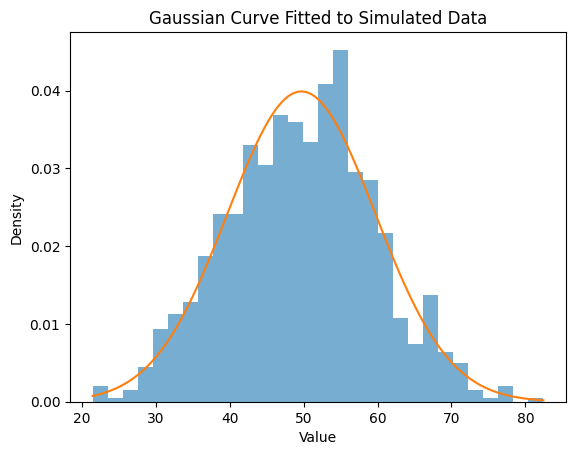

In [4]:

mean = data.mean()
std = data.std()

print("Mean:", mean)
print("Standard Deviation:", std)

x = np.linspace(data.min(), data.max(), 100)
y = norm.pdf(x, mean, std)

plt.hist(data, bins=30, density=True, alpha=0.6)
plt.plot(x, y)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Gaussian Curve Fitted to Simulated Data")

plt.show()



# 9. Chuyển sang dữ liệu thật: Titanic dataset

Bây giờ ta sẽ dùng dữ liệu Titanic.

Ta sẽ phân tích cột:

```python
age
```

Tức là tuổi của hành khách trên tàu Titanic.

Mục tiêu:

- Xem tuổi hành khách phân bố như thế nào
- Tính mean và standard deviation
- Vẽ histogram
- Vẽ đường Gaussian tương ứng


In [5]:

titanic = pd.read_csv("../data/titanic/Titanic-Dataset.csv")

titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



# 10. Xem thông tin dữ liệu Titanic


In [6]:

titanic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB



# 11. Lấy cột Age

Trong dataset Titanic, cột tuổi là:

```python
age
```

Dữ liệu thật thường có giá trị bị thiếu, nên ta dùng:

```python
dropna()
```

để bỏ các dòng không có tuổi.


In [8]:
age = titanic["Age"].dropna()

print(age.head())
print("Number of values:", len(age))


0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64
Number of values: 714



# 12. Tính mean và standard deviation của Age


In [9]:

age_mean = age.mean()
age_std = age.std()

print("Mean Age:", age_mean)
print("Standard Deviation of Age:", age_std)


Mean Age: 29.69911764705882
Standard Deviation of Age: 14.526497332334042



# 13. Vẽ histogram tuổi hành khách Titanic

Histogram cho ta biết dữ liệu thật phân bố ra sao.


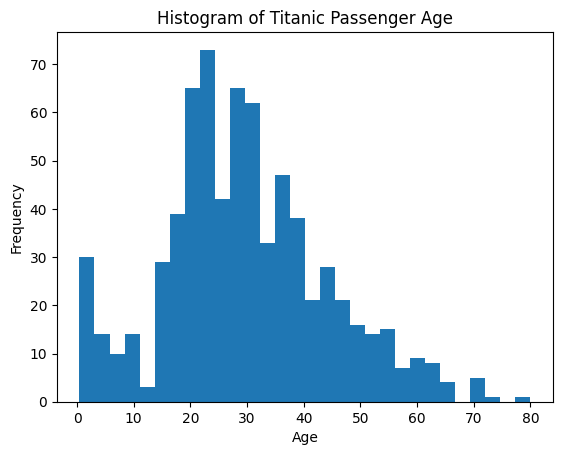

In [10]:

plt.hist(age, bins=30)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram of Titanic Passenger Age")

plt.show()



# 14. Vẽ histogram dạng density

Muốn so sánh histogram với đường Gaussian thì nên dùng:

```python
density=True
```

Vì Gaussian curve là dạng **mật độ xác suất / probability density**, không phải số lượng tuyệt đối.


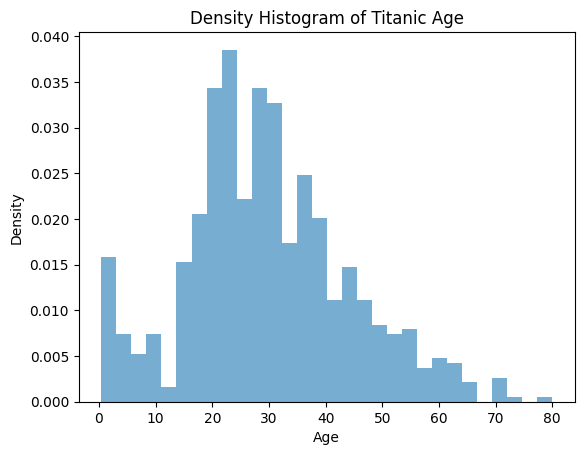

In [11]:

plt.hist(age, bins=30, density=True, alpha=0.6)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Density Histogram of Titanic Age")

plt.show()



# 15. Vẽ đường Gaussian từ dữ liệu Titanic

Ta dùng mean và standard deviation của cột `age` để tạo đường Gaussian.


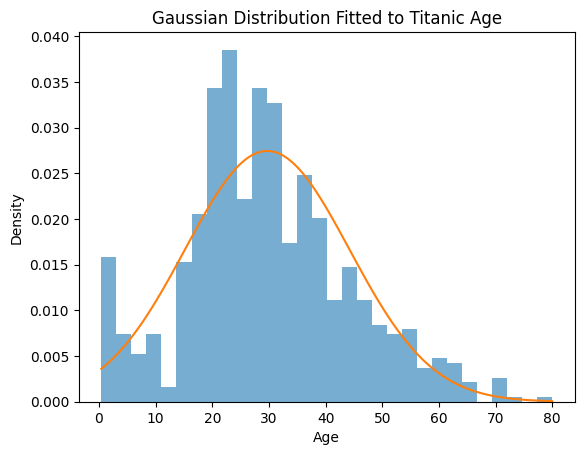

In [12]:

x = np.linspace(age.min(), age.max(), 100)
y = norm.pdf(x, age_mean, age_std)

plt.hist(age, bins=30, density=True, alpha=0.6)
plt.plot(x, y)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Gaussian Distribution Fitted to Titanic Age")

plt.show()



# 16. Giải thích kết quả

Biểu đồ gồm 2 phần:

## Histogram

Histogram thể hiện phân phối thật của tuổi hành khách Titanic.

## Gaussian curve

Đường cong Gaussian là đường lý thuyết được tạo từ:

- Mean age
- Standard deviation of age

Nếu histogram gần giống đường cong Gaussian, ta có thể nói dữ liệu **gần phân phối chuẩn**.

Nhưng nếu histogram lệch nhiều, có nhiều đỉnh, hoặc bị lệch trái/lệch phải, thì dữ liệu **không hoàn toàn Gaussian**.



# 17. Dữ liệu Age của Titanic có thật sự Gaussian không?

Thường thì tuổi hành khách Titanic **không hoàn toàn là Gaussian hoàn hảo**.

Lý do:

- Có trẻ em, người lớn, người già trộn chung
- Dữ liệu tuổi bị thiếu ở nhiều dòng
- Nhóm hành khách không phải mẫu ngẫu nhiên hoàn hảo của toàn bộ dân số
- Có thể có nhiều nhóm tuổi khác nhau

Vì vậy, Gaussian curve ở đây chủ yếu để:

> So sánh dữ liệu thật với một phân phối chuẩn lý thuyết.



# 18. Thử với cột khác: Fare

Ta có thể thử vẽ Gaussian cho cột `fare`.

`fare` là giá vé hành khách đã trả.


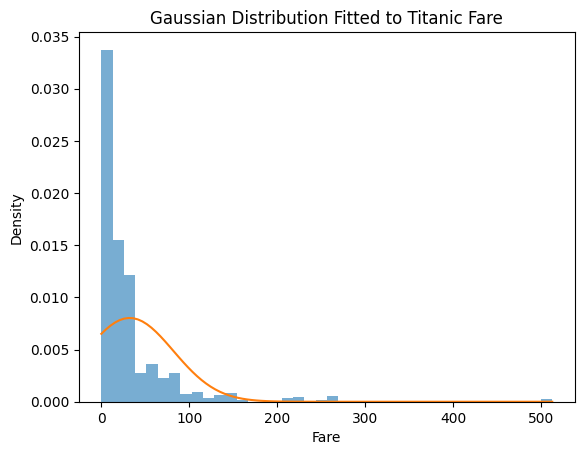

Mean Fare: 32.204207968574636
Standard Deviation of Fare: 49.6934285971809


In [14]:

fare = titanic["Fare"].dropna()

fare_mean = fare.mean()
fare_std = fare.std()

x = np.linspace(fare.min(), fare.max(), 100)
y = norm.pdf(x, fare_mean, fare_std)

plt.hist(fare, bins=40, density=True, alpha=0.6)
plt.plot(x, y)

plt.xlabel("Fare")
plt.ylabel("Density")
plt.title("Gaussian Distribution Fitted to Titanic Fare")

plt.show()

print("Mean Fare:", fare_mean)
print("Standard Deviation of Fare:", fare_std)



# 19. Nhận xét về Fare

Cột `fare` thường **không giống Gaussian**.

Lý do:

- Phần lớn hành khách trả giá vé thấp
- Một số ít hành khách trả giá vé rất cao
- Dữ liệu bị lệch phải / right-skewed

Đây là ví dụ tốt để hiểu:

> Không phải dữ liệu thật nào cũng có phân phối Gaussian.



# 20. Kết luận cần nhớ

## Gaussian Distribution

Là phân phối hình chuông, trong đó dữ liệu tập trung quanh mean và giảm dần khi đi xa mean.

## Mean

Cho biết trung tâm của dữ liệu.

## Standard Deviation

Cho biết dữ liệu phân tán rộng hay hẹp.

## Trong bài Titanic

Ta dùng cột `age` để:

1. Lấy dữ liệu thật
2. Tính mean và standard deviation
3. Vẽ histogram
4. Vẽ Gaussian curve
5. So sánh dữ liệu thật với phân phối chuẩn lý thuyết

## Câu note ngắn gọn

Gaussian Distribution là phân phối xác suất hình chuông, được xác định bởi mean và standard deviation. Khi có dữ liệu thật, ta có thể vẽ histogram rồi chồng đường Gaussian lên để kiểm tra dữ liệu có gần phân phối chuẩn hay không.



# 21. Bài tập tự luyện

## Bài 1

Vẽ Gaussian distribution cho cột `age`, nhưng đổi số bins thành:

```python
bins=10
bins=20
bins=50
```

Quan sát xem biểu đồ thay đổi như thế nào.

## Bài 2

Vẽ Gaussian distribution cho cột `fare`.  
Nhận xét xem `fare` có giống phân phối chuẩn không.

## Bài 3

Chia dữ liệu theo giới tính:

```python
male_age
female_age
```

Sau đó vẽ Gaussian distribution riêng cho từng nhóm.

Gợi ý:

```python
male_age = titanic[titanic["sex"] == "male"]["age"].dropna()
female_age = titanic[titanic["sex"] == "female"]["age"].dropna()
```


In [ ]:

# Bài 3 gợi ý lời giải

male_age = titanic[titanic["sex"] == "male"]["age"].dropna()
female_age = titanic[titanic["sex"] == "female"]["age"].dropna()

male_mean = male_age.mean()
male_std = male_age.std()

female_mean = female_age.mean()
female_std = female_age.std()

x_male = np.linspace(male_age.min(), male_age.max(), 100)
y_male = norm.pdf(x_male, male_mean, male_std)

x_female = np.linspace(female_age.min(), female_age.max(), 100)
y_female = norm.pdf(x_female, female_mean, female_std)

plt.hist(male_age, bins=30, density=True, alpha=0.5)
plt.plot(x_male, y_male)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Gaussian Distribution Fitted to Male Passenger Age")

plt.show()

plt.hist(female_age, bins=30, density=True, alpha=0.5)
plt.plot(x_female, y_female)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Gaussian Distribution Fitted to Female Passenger Age")

plt.show()
